This notebook will address the normality of residuals and homoscedasticity assumptions of linear regression, as well as model adequacy. The best remedies for violations of the two assumptions are transformations and robust regression techniques. Therefore, various different types of regression will be tested, each using multiple transformations of the dependent variable (transforming the independent variables is unnecessary as all of their values are either 0 or 1). The metrics caluclated at the end of the previous notebook for testing the assumptions (Jarque-Bera, Anderson-Darling, etc.) as well as the values for determining model adequacy (adjusted R-squared, F-statistic, etc.) will be recorded for each variation in a table so that the most ideal one can be selected. Lastly, while the assumption regarding independence of errors is already met, the Durbin-Watson statistic will be checked in the new models to ensure that it stays in the acceptable range.

### The first cells import the necessary packages, mount Google Drive, and upload the data.

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.diagnostic as diag
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tools.tools import pinv_extended
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.linear_model import ElasticNetCV
from scipy.stats import boxcox
from scipy.linalg import toeplitz
from fractions import Fraction

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
Laptop_Data_Reduced = pd.read_csv('/content/drive/MyDrive/Personal Files/Regression Practice/Laptop_Data_Reduced.csv')
Laptop_Data_Reduced.head()

,Company_Asus,Company_Dell,Company_HP,Company_Lenovo,Company_MSI,Company_Other,Company_Toshiba,OpSys_Linux,OpSys_No OS,OpSys_Windows 7,...,MemoryGB1_Other,MemoryType1_HDD,ScreenResolution_1600x900,ScreenResolution_2560x1440,ScreenResolution_3840x2160,ScreenDisplayType_None,ScreenDisplayType_Quad HD+,ScreenIPSPanel_Yes,ScreenTouchscreen_Yes,Price
0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,30636.000
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,21312.000
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,79653.600
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,41025.600
4,0,0,1,0,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,20986.992


### This cell splits the data into training and test datasets using "Price" as the dependent variable. It also adds constants to the X_train and X_test data.

MinMaxScaler() is unnecessary as all remaining independent variables are one-hot encoded categorical variables.

In [ ]:
X = Laptop_Data_Reduced.drop('Price', axis=1)
y = Laptop_Data_Reduced['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

X_train_constant = sm.add_constant(X_train)
X_test_constant = sm.add_constant(X_test)

### This cell performs a Box-Cox transformation on the y_train data and returns the optimal lambda value.

This is done so that lambda values around this result can be chosen for the transformations in the following cell.

In [ ]:
y_train_temp, optimal_lambda = boxcox(y_train)
print(optimal_lambda)

0.09457515233235643


### These cells accept a series of lambda values to serve as the basis of subsequent transfromations and then processes them.

This code accepts the lambda values. These are all put in a single list, and the decimal values are also stored in a separate list from the fractions and whole numbers so that the function in the following cell can be used.

In [ ]:
transformation_values_factions_and_whole = [-2, -3/2, -1, -1/2, -1/3, -1/4, -1/5, 0, 1/5, 1/4, 1/3, 1/2, 1, 3/2, 2]
transformation_values_decimals = [optimal_lambda]
transformation_values = sorted(transformation_values_factions_and_whole + transformation_values_decimals)

The first cell uses a function to get the transformation values that will be displayed. Trial and error determined that power, natural log, and associated compound transformations return the most ideal models; exponential models and their associated compond transformations did not return great results. Therefore, for each lambda value, two Box-Cox transformations will be performed: one based on the y_train data and one based on the natrual log of the y_train data. The display values will be returned in the form of "x^power" and "ln^power(x)", except when lambda is 0, in which case the values will be "ln(x)" and "ln(ln(x))." For the fractional values (which are grouped with the whole numbers), use of the Fraction class is necessary to prevent inaccuracy from decimal rounding. Also, If lambda is equal to the optimal lambda from the previous cell, it will be rounded to two decimal places. Any other decimal values will be displayed as is.

In [ ]:
def display_value (transformation_value):
  if transformation_value == 0:
    return 'ln(x)', 'ln(ln(x))'
  elif transformation_value in transformation_values_factions_and_whole:
    return 'x^' + str(Fraction(transformation_value).limit_denominator(10)), 'ln^' + str(Fraction(transformation_value).limit_denominator(10)) + '(x)'
  elif transformation_value == optimal_lambda:
    return 'x^' + str(round(transformation_value, 2)), 'ln^' + str(round(transformation_value, 2)) + '(x)'
  else:
    return 'x^' + str(transformation_value), 'ln^' + str(transformation_value) + '(x)'

This cell acquires the display values using the lambda values and function above, and it arranges them with all of the "x^power" transformations first, followed by all of the "ln^power(x)" transformations. It also removes the "ln^1(x)" transformation, as it is the same as "ln(x)."

In [ ]:
transformation_values_display_normal = [display_value(i)[0] for i in transformation_values]
transformation_values_display_compound = [display_value(i)[1] for i in transformation_values]
transformation_values_display = transformation_values_display_normal + transformation_values_display_compound
transformation_values_display.remove('ln^1(x)')

### These cells define multiple functions that are used for the different types of regression.

The first function is for transforming the y_train data. It should be noted that the boxcox function produces erronenous results for some transformations; therefore, the numpy power and log functions were used instead. This has no effect on the regression models that follow. If y is equal to the optimal lambda, it is converted from rounded form back into unrounded form. Next, the transformations for "ln(x)" and "ln(ln(x))" are handled, followed by the transformations on y_train, and lastly, the transformations on log of y_train. It's important to remember that natrual log transformations require positive inputs, and some of the compound transformations require inputs greater than one.  Fortunately, all untransformed y values in are in appropriate range.

In [ ]:
def transform (array, i):
  if str(round(optimal_lambda, 2)) in i:
    i = i.replace(str(round(optimal_lambda, 2)), str(optimal_lambda))

  if i == 'ln(x)':
    return np.log(array)
  elif i == 'ln(ln(x))':
    return np.log(np.log(array))
  elif 'x^' in i:
    value = eval(re.search("-?(\d+\/\d+|\d*\.?\d+)", i)[0])
    return np.power(array, value)
  else:
    value = eval(re.search("-?(\d+\/\d+|\d*\.?\d+)", i)[0])
    return np.power(np.log(array), value)

The next function is for obtaining model residuals for both the train and test data. The ".resid" attribute of the results is not used, as it isn't avaialble for the coming elastic net model.

In [ ]:
def obtain_residuals (model_or_reg_model):
  predictions_train = model_or_reg_model.predict(X_train_constant)
  residuals_train = y_train_trans - predictions_train
  predictions_test = model_or_reg_model.predict(X_test_constant)
  residuals_test = y_test_trans - predictions_test
  return residuals_train, residuals_test

The next three functions are "sub" functions that will be used in the next cell. The first caluclates adjusted R-squared for the test data, the second calcualtes adjusted pseudo R-squared, and the third checks if a model has an attribute (returning the attribute if it's present and a blank value if it's not).

In [ ]:
def test_adj_r2 (model_or_summary_base):
  predictions_test = model_or_summary_base.predict(X_test_constant)
  r2 = r2_score(y_test_trans, predictions_test)
  n, p = len(y_test_trans), len(model_or_summary_base.params) - 1
  adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
  return adjusted_r2

def adj_pseudo_rsquared (model_or_summary_base):
  pseudo_r2 = model_or_summary_base.pseudo_rsquared()
  n, p = model_or_summary_base.nobs, len(model_or_summary_base.params) - 1
  adj_pseudo_r2 = 1 - ((n - 1) / (n - p - 1)) * (1 - pseudo_r2)
  return adj_pseudo_r2

def has_attribute (model_or_summary_base, attribute):
  if hasattr(model_or_summary_base, attribute):
    return getattr(model_or_summary_base, attribute)
  else:
    return ''

This function creates new rows for the summary table. It first checkes if the model has the adjusted R-squared attribute; if it does, the adjusted R-squared is calculated for the training and test data. If it isn't present, the adjusted pseudo R-squared is calculated for the training data; adjusted pseudo R-squared isn't readily available for the test data, so this is left blank. If neither metric is available, blank values are given. The function then calcualtes the remaining metrics (F-statistic, Durbin-Watson, Jarque-Bera, Anderson-Darling, White's, AIC, and BIC) and applies the has_attribute function as needed. The results are all arranged as a row and added to the summary table, which the function then returns.

In [ ]:
def new_row (model_or_summary_base, residuals_train, residuals_test, name):
  if hasattr(model_or_summary_base, 'rsquared_adj'):
    adj_r2_train, adj_r2_test = model_or_summary_base.rsquared_adj, test_adj_r2(model_or_summary_base)
  elif hasattr(model_or_summary_base, 'pseudo_rsquared'):
    adj_r2_train, adj_r2_test = adj_pseudo_rsquared(model_or_summary_base), ''
  else:
    adj_r2_train, adj_r2_test = '', ''

  f_stat = has_attribute(model_or_summary_base, 'f_pvalue')
  dw = durbin_watson(residuals_train)
  jb = jarque_bera(residuals_train)[1]
  ad_train = diag.normal_ad(residuals_train)[1]
  ad_test = diag.normal_ad(residuals_test)[1]
  w_train = diag.het_white(residuals_train, X_train_constant)[1]
  aic = has_attribute(model_or_summary_base, 'aic')
  bic = has_attribute(model_or_summary_base, 'bic')

  new_row_data = [i, name, adj_r2_train, adj_r2_test, f_stat, dw, jb, ad_train, ad_test, w_train, aic, bic]
  summary_table.loc[len(summary_table)] = new_row_data
  return summary_table

### This cell loads the summary table.

The first line creates the table during the first run through of the code; it's since been commented out. For subsequent runs of the code, the table already exists and is loaded so that new entries can be added if needed. Different versions of the table were made during the development of this code, and it was finalized in its fifth version. As such, the table's name is "Summary_Table_5."

In [ ]:
#summary_table = pd.DataFrame(columns = ['Transformation', 'Model', 'Adj R2 (Train)', 'Adj R2 (Test)', 'F Statistic', 'Durbin Watson', 'Jarque Bera', 'Anderson Darling (Train)', 'Anderson Darling (Test)', "White's (Train)", 'AIC', 'BIC'])
summary_table = pd.read_csv('/content/drive/MyDrive/Personal Files/Regression Practice/Summary_Table_5.csv')

### The following cells peform the various types of regression on the different transformations.

The first cell performs Ordinary Least Squares (OLS) regression. For every value in the list of transformations established earlier, the cell checks if an OLS model already exists in the table. If not, it uses the previously defined functions to transform the data, run the regression, get the residuals, and make the new row and add it to the summary table.

In [ ]:
for i in transformation_values_display:
  if not ((summary_table['Transformation'] == i) & (summary_table['Model'] == 'OLS')).any():
    y_train_trans, y_test_trans = transform(y_train, i), transform(y_test, i)

    model_ols = sm.OLS(y_train_trans, X_train_constant).fit()
    residuals_train_ols, residuals_test_ols = obtain_residuals(model_ols)
    summary_table = new_row(model_ols, residuals_train_ols, residuals_test_ols, 'OLS')

The next form of regression, OLS Elastic Net, is more complicated. A table for the optimal alpha and l1 ratio values is created to store them for each transfromation. First, a function is defined that takes an array of values and plugs them into the function "0.9 * (x-1)^3 + 1." This function was chosen because for x values between 0 and 1, the results will be between 0.1 and 1, with more of the values being close to 1, and this arrangement of outputs is ideal for use as l1 ratios. The inverse of the function is also given so that the idal input can be recovered and used to narrow things down further. The second function takes a set of alpha and l1 ratio values and uses ElasticNetCV to find the ideal ones.

In [ ]:
def function(array):
  result = 0.9 * (array - 1)**3 + 1
  inverse = abs((array - 1) / 0.9)**(1/3) * np.where((array) < 1, -1, 1) + 1
  return result, inverse

def elastic_net_search (alpha_values, l1_ratio_values):
  elastic_net_cv = ElasticNetCV(alphas = alpha_values, l1_ratio = l1_ratio_values, cv = cv)
  elastic_net_cv.fit(X_train, y_train_trans)
  return elastic_net_cv.alpha_, elastic_net_cv.l1_ratio_

Next, the cell contains the code to either create or load the transformations values table, similar to the code three cells prior. This table was finialized in its fourth version, which is why it's named "Transformation_Values_Table_4."

In [ ]:
#transformation_values_table = pd.DataFrame(columns = ['Transformation', 'Best Alpha', 'Best L1'])
transformation_values_table = pd.read_csv('/content/drive/MyDrive/Personal Files/Regression Practice/Transformation_Values_Table_4.csv')

For every transformation not already in this new table, the y_train data is transformed and the optimal alpha and l1 ratio parameters are chosen by making use of RepeatedKFold and the elastic_net_search function defined above. One set of values is tested for each, and the results are used to generate new values which can help narrow down the ideal parameters even further. The first set of alpha values comes in the form 5 * 10^n, and the second set checks values from 1 to 10 multiplied by 10 raised to the same n. The first set of l1 ratios are caluclated by plugging a set of values between 0 and 1 into the mathematical function defined earlier. The results are tested, and the ideal one is converted back to its original form so that a smaller interval of values around it can be tested in the same way. The final results for both parameters are made into a row and then added to the table.

In [ ]:
for i in transformation_values_display:
  if i not in [element for element in transformation_values_table['Transformation'].tolist()]:
    y_train_trans = transform(y_train, i)
    cv = RepeatedKFold(n_splits = 10, n_repeats = 5, random_state = 1)

    alpha_values_1, l1_ratio_values_1 = [5e-3, 5e-2, 5e-1, 5], function(np.arange(0.05, 1, 0.1))[0]
    best_alpha_1, best_l1_ratio_1 = elastic_net_search(alpha_values_1, l1_ratio_values_1)

    alpha_values_2 = (np.arange(best_alpha_1 / 5, best_alpha_1 * 2.0000001, best_alpha_1 / 5))
    best_l1_ratio_value_original = function(best_l1_ratio_1)[1]
    l1_ratio_values_2 = function(np.arange(best_l1_ratio_value_original - 0.05, best_l1_ratio_value_original + 0.06, 0.01))[0]
    best_alpha_2, best_l1_ratio_2 = elastic_net_search(alpha_values_2, l1_ratio_values_2)

    new_row_data_transformation = [i, best_alpha_2, best_l1_ratio_2]
    transformation_values_table.loc[len(transformation_values_table)] = new_row_data_transformation

This cell resets the index and displays the table. Some extra code for modifying the table is commented out, but it's kept in case it needs to be used later.

In [ ]:
#transformation_values_table = transformation_values_table.drop([0], axis=0)
#transformation_values_table.loc[0, 'Lambda'] = ''

transformation_values_table.reset_index(drop=True, inplace=True)
display(transformation_values_table)

,Transformation,Best Alpha,Best L1
0,x^-2,10.000,0.100000
1,x^-3/2,10.000,0.100000
2,x^-1,10.000,0.100000
3,x^-1/2,10.000,0.100000
4,x^-1/3,0.001,0.100000
5,x^-1/4,0.001,0.100000
6,x^-1/5,0.001,0.100000
7,ln(x),0.001,0.100000
8,x^0.09,0.001,0.100000
9,x^1/5,0.001,0.100000


This cell saves the table of transformation values so that the whole table doesn't need to be recreated in subsequent runs of the code.

In [ ]:
transformation_values_table.to_csv('/content/drive/MyDrive/Personal Files/Regression Practice/Transformation_Values_Table_4.csv', index=False)

This cell performs the elastic net regression. Similar to the OLS cell earlier, each transformation is cheked to see if its elastic net model is already present in the summary table. If not, it uses the optimal alpha value and l1 ratio as as well as the transformed data to perform the regression. The residuals are obtained, and the new row is made and added to the summary table as before.

In [ ]:
for i in transformation_values_display:
  if not ((summary_table['Transformation'] == i) & (summary_table['Model'] == 'OLS Elastic')).any():
    best_alpha = transformation_values_table.loc[transformation_values_table['Transformation'] == i, 'Best Alpha'].iloc[0]
    best_l1_ratio = transformation_values_table.loc[transformation_values_table['Transformation'] == i, 'Best L1'].iloc[0]
    y_train_trans, y_test_trans = transform(y_train, i), transform(y_test, i)

    model_ols_elastic = sm.OLS(y_train_trans, X_train_constant)
    model_regularized_ols_elastic = model_ols_elastic.fit_regularized(method = 'elastic_net', alpha = best_alpha, L1_wt = best_l1_ratio)
    pinv_wexog,_ = pinv_extended(model_ols_elastic.wexog)
    model_regularized_ols_elastic_cov_params = np.dot(pinv_wexog, np.transpose(pinv_wexog))
    summary_base_ols_elastic = sm.regression.linear_model.OLSResults(model_ols_elastic, model_regularized_ols_elastic.params, model_regularized_ols_elastic_cov_params)

    residuals_train_ols_elastic, residuals_test_ols_elastic = obtain_residuals(model_regularized_ols_elastic)
    summary_table = new_row(summary_base_ols_elastic, residuals_train_ols_elastic, residuals_test_ols_elastic, 'OLS Elastic')

This cell performs Weighted Least Squares (WLS) regression. It's similar to the OLS code, though it has the addition of weights, which are obtained using the residuals of OLS regression.

In [ ]:
for i in transformation_values_table['Transformation']:
  if not ((summary_table['Transformation'] == i) & (summary_table['Model'] == 'WLS')).any():
    y_train_trans, y_test_trans = transform(y_train, i), transform(y_test, i)

    model_ols = sm.OLS(y_train_trans, X_train_constant).fit()
    residuals_train_ols, residuals_test_ols = obtain_residuals(model_ols)
    weights_train = 1 / sm.OLS(abs(residuals_train_ols), model_ols.predict(X_train_constant)).fit().fittedvalues**2
    weights_test = 1 / sm.OLS(abs(residuals_test_ols), model_ols.predict(X_test_constant)).fit().fittedvalues**2

    model_wls = sm.WLS(y_train_trans, X_train_constant, weights = weights_train).fit()
    residuals_train_wls, residuals_test_wls = obtain_residuals(model_wls)
    residuals_train_wls_weighted, residuals_test_wls_weighted = residuals_train_wls * np.sqrt(weights_train), residuals_test_wls * np.sqrt(weights_test)
    summary_table = new_row(model_wls, residuals_train_wls_weighted, residuals_test_wls_weighted, 'WLS')

This cell performs Generalized Least Squares (GLS) regression and adds rows to the table using the previous technique.

Adapted from: https://www.geeksforgeeks.org/machine-learning/implementing-generalized-least-squares-gls-in-python/ <br>
Date Retrieved: 2024-07-17 <br>
Original Author: Unknown <br>

In [ ]:
for i in transformation_values_table['Transformation']:
  if not ((summary_table['Transformation'] == i) & (summary_table['Model'] == 'GLS')).any():
    y_train_trans, y_test_trans = transform(y_train, i), transform(y_test, i)

    model_ols = sm.OLS(y_train_trans, X_train_constant).fit()
    residuals_train_ols, residuals_test_ols = obtain_residuals(model_ols)

    for _ in range(5):
      resid_fit = sm.OLS(residuals_train_ols[1:].reset_index(drop=True), sm.add_constant(residuals_train_ols[:-1].reset_index(drop=True))).fit()
      rho = resid_fit.params.iloc[1]
      sigma = rho**toeplitz(np.arange(len(residuals_train_ols)))
      model_gls = sm.GLS(y_train_trans, X_train_constant, sigma=sigma).fit()
      residuals_train_gls, residuals_test_gls = obtain_residuals(model_gls)

    summary_table = new_row(model_gls, residuals_train_gls, residuals_test_gls, 'GLS')

The last regression form is a Generalized Lienar Model (GLM). First, a histogram of the OLS residuals is created to get a general idea of the function family to use.

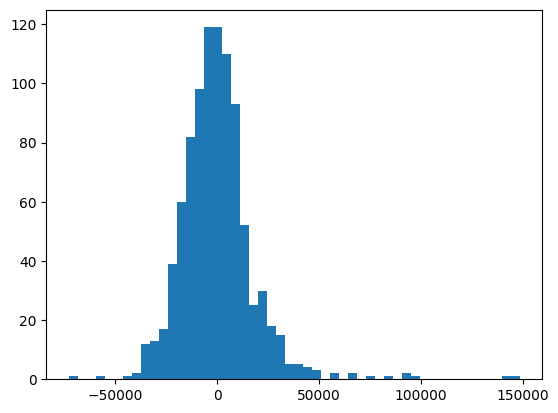

In [ ]:
model_ols = sm.OLS(y_train, X_train_constant).fit()
residuals_train = model_ols.resid
plt.hist(residuals_train, bins=50)
plt.show()

Judging by the shape of the curve, a gamma distribution seems most appropriate. The following cell perfoms gamma regression on the transformed training data and adds rows to the table in the same manner as the cells before. It should be noted that adjusted R-squared isn't applicable to this model, so adjusted pseudo R-squared is used instead in the summary table. As stated earlier, this metric isn't readily avaialble for the test data, so it's only calculated on the training data. Furthermore, the link function did not accept custom transformations, so the transformations were limited to the train and test data. Lastly, the Log link function was used, though the type of link function (Log, Inverse, etc.) made little difference in the final results.

In [ ]:
for i in transformation_values_table['Transformation']:
  if not ((summary_table['Transformation'] == i) & (summary_table['Model'] == 'GLM')).any():
    y_train_trans, y_test_trans = transform(y_train, i), transform(y_test, i)

    model_glm = sm.GLM(y_train_trans, X_train_constant, family = sm.families.Gamma(link = sm.families.links.Log())).fit()
    residuals_train_glm, residuals_test_glm = obtain_residuals(model_glm)
    summary_table = new_row(model_glm, residuals_train_glm, residuals_test_glm, 'GLM')

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


Robust Linear Models (RLM) were considered for use, but it lacked too many of the metrics used in other models for proper comparisons to be made.

### The table is then saved.

This cell displays the final few rows of the summary table; this is done to make sure it turned out properly before it's saved. Commented code for modifying the table is kept in the event that it's needed in subsequent runs.

In [ ]:
#summary_table = summary_table.drop([20], axis=0)
#summary_table.loc[0, 'Transformation'] = 'x^1'
#summary_table = summary_table.sort_values(by='Transformation')
#summary_table.reset_index(drop=True, inplace=True)

display(summary_table.tail(40))

,Transformation,Model,Adj R2 (Train),Adj R2 (Test),F Statistic,Durbin Watson,Jarque Bera,Anderson Darling (Train),Anderson Darling (Test),White's (Train),AIC,BIC
115,ln^-1/5(x),GLS,0.842714,0.778222,0.0,1.956008,1.119962e-02,2.186015e-01,1.950220e-01,3.175057e-07,-8237.830833,-8000.644053
116,ln(ln(x)),GLS,0.842299,0.776686,0.0,1.957500,6.337150e-03,2.022445e-01,1.839390e-01,3.338071e-07,-4339.120062,-4101.933282
117,ln^0.09(x),GLS,0.842091,0.775942,0.0,1.958211,4.663896e-03,1.911598e-01,1.777752e-01,3.386245e-07,-8328.664458,-8091.477678
118,ln^1/5(x),GLS,0.841852,0.7751,0.0,1.959005,3.217029e-03,1.777298e-01,1.706718e-01,3.416797e-07,-6459.208131,-6222.021351
119,ln^1/4(x),GLS,0.841735,0.774696,0.0,1.959383,2.667212e-03,1.711734e-01,1.672886e-01,3.422629e-07,-5819.461843,-5582.275063
120,ln^1/3(x),GLS,0.841536,0.774015,0.0,1.960014,1.919387e-03,1.595278e-01,1.616600e-01,3.419966e-07,-4910.647826,-4673.461046
121,ln^1/2(x),GLS,0.841123,0.772628,0.0,1.961281,9.313267e-04,1.358577e-01,1.496038e-01,3.369141e-07,-3410.473755,-3173.286975
122,ln^3/2(x),GLS,0.838189,0.76357,0.0,1.968957,1.341870e-06,3.744478e-02,8.601249e-02,2.163283e-07,3102.767762,3339.954542
123,ln^2(x),GLS,0.836435,0.758559,0.0,1.972797,8.150914e-09,1.458796e-02,5.380994e-02,1.412476e-07,5874.639352,6111.826132
124,x^-2,GLM,0.995483,,,1.965032,0.000000e+00,0.000000e+00,0.000000e+00,4.981279e-21,-39042.256728,-5847.573359


This cell saves the table so that the information within doesn't need to be recreated in subsequent runs.

In [ ]:
summary_table.to_csv('/content/drive/MyDrive/Personal Files/Regression Practice/Summary_Table_5.csv', index=False)

### The last cell displays the table so that the best model and transformation can be chosen.

It filters several columns to limit them to ideal values, making it easier to choose among the entries.

In [ ]:
summary_table_reduced = summary_table[summary_table['Adj R2 (Train)'] >= 0.8]
summary_table_reduced = summary_table_reduced[summary_table['Anderson Darling (Train)'] >= 0.05]
summary_table_reduced = summary_table_reduced[summary_table_reduced['Anderson Darling (Test)'] >= 0.05]
summary_table_reduced = summary_table_reduced[summary_table_reduced['Jarque Bera'] >= 0.05]
display(summary_table_reduced)

/tmp/ipython-input-28-518662705.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  summary_table_reduced = summary_table_reduced[summary_table['Anderson Darling (Train)'] >= 0.05]


,Transformation,Model,Adj R2 (Train),Adj R2 (Test),F Statistic,Durbin Watson,Jarque Bera,Anderson Darling (Train),Anderson Darling (Test),White's (Train),AIC,BIC
5,x^-1/4,OLS,0.844861,0.788054,0.0,1.952486,0.055533,0.120076,0.205820,1.187292e-07,-7515.610383,-7278.423604
6,x^-1/5,OLS,0.844292,0.784784,0.0,1.955527,0.056620,0.200839,0.218480,2.070332e-07,-6932.654708,-6695.467928
17,ln^-3/2(x),OLS,0.844483,0.786877,0.0,1.952693,0.050281,0.134095,0.206911,1.168984e-07,-10235.944445,-9998.757665
78,ln^-2(x),WLS,0.835736,0.787377,0.0,1.945793,0.066115,0.158838,0.095988,1.694569e-07,-11936.266478,-11699.079698
79,ln^-3/2(x),WLS,0.837663,0.785226,0.0,1.949832,0.066605,0.238123,0.117386,1.950944e-07,-10251.816429,-10014.629649
98,x^-1/4,GLS,0.845018,0.788209,0.0,1.946472,0.051131,0.115955,0.212544,1.192342e-07,-7516.202891,-7279.016111
99,x^-1/5,GLS,0.844419,0.784931,0.0,1.949939,0.052987,0.191483,0.226694,2.084338e-07,-6933.173236,-6695.986456
130,x^-1/5,GLM,0.995123,,,1.965442,0.061386,0.201992,0.125495,1.025013e-07,-6942.929195,-6058.505232
142,ln^-1(x),GLM,0.995403,,,1.960461,0.052190,0.233816,0.171751,1.593597e-07,-8787.756013,-6060.248822


While the pseudo R-squared seems ideal in the GLM entries, it's suspiciously high and suggests overfitting. Based on the AIC and BIC values of the remaining rows, the WLS model with a transformation of "ln^-2(x)" seems like the best choice. All the values here seem ideal except for the White's test value, which is well below the critical value of 0.05 (as is the case in all rows of the summary table). This is most likely because of the large number of observations, which cause even slight deviations from homoscedasticity to be noticed in the test. Robust standard errors can be used in the final model, and a scatter plot will be used in the next notebook to see if the distribution seems random, thus suggesting reasonable homoscedasticity. Other slight modifications can be made to see if the White's test value can be improved further.